# 📦 Benchmark : uv vs pip vs poetry

Ce notebook compare les performances des trois gestionnaires de paquets Python :
- **pip** — le gestionnaire officiel Python
- **uv** — le nouveau gestionnaire ultra-rapide (écrit en Rust)
- **poetry** — gestionnaire orienté projets et lock file

### Métriques mesurées
1. Installation d'un paquet simple (`requests`)
2. Installation avec cache chaud
3. Installation de paquets lourds (`numpy`, `pandas`, `scipy`)
4. Résolution de dépendances uniquement (dry-run / lock)

In [7]:
!pip install uv pip poetry

In [8]:
import subprocess, time, os, shutil, tempfile, sys, json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Enrichir le PATH pour que Jupyter trouve les outils installés dans le shell
extra = [
    os.path.expanduser("~/.local/bin"),
    os.path.expanduser("~/.cargo/bin"),
    "/usr/local/bin", "/usr/bin",
    str(Path(sys.executable).parent),
    str(Path(sys.executable).parent.parent / "bin"),
]
os.environ["PATH"] = ":".join(extra) + ":" + os.environ.get("PATH", "")

def find_tool(name):
    # pip : toujours utiliser 'python -m pip' pour éviter les soucis de PATH
    if name == "pip":
        try:
            subprocess.check_output([sys.executable, "-m", "pip", "--version"],
                                     stderr=subprocess.DEVNULL)
            return "__pip__"   # marqueur interne
        except Exception:
            return None
    return shutil.which(name)

tools = {}
for t in ["pip", "uv", "poetry"]:
    p = find_tool(t)
    tools[t] = p
    status = "OK  " + (p if p else "")
    print(t.ljust(10) + " -> " + ("✅ " + status if p else "❌ non trouvé"))

missing = [t for t, p in tools.items() if not p]
if missing:
    print("\n⚠️  Manquants : " + str(missing))
else:
    print("\n✅ Tous les outils sont disponibles !")
    print("Python -> " + sys.executable)


pip        -> ✅ OK  __pip__
uv         -> ✅ OK  /usr/local/bin/uv
poetry     -> ✅ OK  /usr/local/bin/poetry

✅ Tous les outils sont disponibles !
Python -> /usr/bin/python3


In [9]:
print("=" * 55)
print("VERSIONS")
print("=" * 55)
cmds = {
    "pip":    [sys.executable, "-m", "pip", "--version"],
    "uv":     ["uv", "--version"],
    "poetry": ["poetry", "--version"],
}
for name, cmd in cmds.items():
    try:
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT).decode().strip()
        print(name.ljust(10) + " -> " + out)
    except Exception as e:
        print(name.ljust(10) + " -> ERREUR: " + str(e))


VERSIONS
pip        -> pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
uv         -> uv 0.11.16 (x86_64-unknown-linux-gnu)
poetry     -> Poetry (version 2.4.1)


In [10]:
def run_bench(cmd, cwd=None, env=None, timeout=300):
    start = time.perf_counter()
    try:
        r = subprocess.run(cmd, capture_output=True, text=True,
                           cwd=cwd, env=env, timeout=timeout)
        return time.perf_counter() - start, r.returncode == 0, r.stdout + r.stderr
    except subprocess.TimeoutExpired:
        return timeout, False, "TIMEOUT"
    except Exception as e:
        return time.perf_counter() - start, False, str(e)

def fmt(s):
    return f"{s*1000:.0f} ms" if s < 1 else f"{s:.2f} s"

def pr(name, elapsed, ok, note=""):
    icon = "✅" if ok else "❌"
    tag  = f" [{note}]" if note else ""
    print(f"  {icon} {name.ljust(10)} -> {fmt(elapsed)}{tag}")

results = {}
print("Utilitaires chargés ✅")


Utilitaires chargés ✅


---
## 🔬 Benchmark 1 : Installation de `requests` (sans cache)

In [13]:
print("=" * 60)
print("BENCHMARK 1 : Install 'requests' — cold (sans cache)")
print("=" * 60)

bench1 = {}
pkg = "requests"

# pip
with tempfile.TemporaryDirectory() as d:
    env = os.environ.copy()
    env["PIP_NO_CACHE_DIR"] = "1"
    venv_dir = os.path.join(d, "venv")
    subprocess.run([sys.executable, "-m", "venv", venv_dir], capture_output=True)
    venv_python = os.path.join(venv_dir, "bin", "python") # Corrected: get python executable from venv
    cmd = [venv_python, "-m", "pip", "install", # Corrected: use venv's python to run pip
           "--no-cache-dir", "-q", pkg]
    t, ok, _ = run_bench(cmd, env=env)
    bench1["pip"] = t
    pr("pip", t, ok)

# uv
with tempfile.TemporaryDirectory() as d:
    env = os.environ.copy()
    env["UV_CACHE_DIR"] = os.path.join(d, "cache")
    cmd = ["uv", "pip", "install", "--no-cache",
           "--python", sys.executable, "-q", pkg]
    t, ok, out = run_bench(cmd, env=env)
    bench1["uv"] = t
    pr("uv", t, ok)

# poetry
with tempfile.TemporaryDirectory() as d:
    proj = Path(d) / "proj"; proj.mkdir()
    (proj / "pyproject.toml").write_text(
        '[tool.poetry]\nname="p"\nversion="0.1.0"\ndescription=""\n'
        'authors=["x <x@x.com>"]\n\n[tool.poetry.dependencies]\npython="^3.8"\n\n'
        '[build-system]\nrequires=["poetry-core"]\nbuild-backend="poetry.core.masonry.api"\n'
    )
    env = os.environ.copy()
    env["POETRY_VIRTUALENVS_IN_PROJECT"] = "true"
    env["POETRY_CACHE_DIR"] = os.path.join(d, "cache")
    cmd = ["poetry", "add", "-q", pkg]
    t, ok, out = run_bench(cmd, cwd=str(proj), env=env)
    bench1["poetry"] = t
    pr("poetry", t, ok)

results["install_simple"] = bench1
print("\n📊 uv est %.1fx plus rapide que pip" % (bench1["pip"] / bench1["uv"]))

BENCHMARK 1 : Install 'requests' — cold (sans cache)
  ❌ pip        -> 21 ms
  ✅ uv         -> 118 ms
  ❌ poetry     -> 2.10 s

📊 uv est 0.2x plus rapide que pip


---
## 🔬 Benchmark 2 : Installation avec cache chaud

In [14]:
print("=" * 60)
print("BENCHMARK 2 : Install 'requests' — warm cache")
print("=" * 60)

bench2 = {}
pkg = "requests"

# pip
with tempfile.TemporaryDirectory() as d:
    env = os.environ.copy(); venv_dir = os.path.join(d, "venv")
    subprocess.run([sys.executable, "-m", "venv", venv_dir], capture_output=True)
    venv_python = os.path.join(venv_dir, "bin", "python") # Corrected
    subprocess.run([venv_python, "-m", "pip", "install", "-q", pkg], capture_output=True) # Corrected
    subprocess.run([venv_python, "-m", "pip", "uninstall", "-y", "-q", pkg], capture_output=True) # Corrected
    t, ok, _ = run_bench([venv_python, "-m", "pip", "install", "-q", pkg], env=env) # Corrected
    bench2["pip"] = t; pr("pip", t, ok, "warm cache")

# uv
with tempfile.TemporaryDirectory() as d:
    cache = os.path.join(d, "cache"); env = os.environ.copy(); env["UV_CACHE_DIR"] = cache
    subprocess.run(["uv", "pip", "install", "--python", sys.executable, "-q", pkg],
                   env=env, capture_output=True)
    t, ok, _ = run_bench(["uv", "pip", "install", "--python", sys.executable, "-q", pkg], env=env)
    bench2["uv"] = t; pr("uv", t, ok, "warm cache")

# poetry
with tempfile.TemporaryDirectory() as d:
    proj = Path(d) / "proj"; proj.mkdir()
    toml_base = ('[tool.poetry]\nname="p"\nversion="0.1.0"\ndescription=""\n'
                 'authors=["x <x@x.com>"]\n\n[tool.poetry.dependencies]\npython="^3.8"\n\n'
                 '[build-system]\nrequires=["poetry-core"]\nbuild-backend="poetry.core.masonry.api"\n')
    (proj / "pyproject.toml").write_text(toml_base)
    env = os.environ.copy()
    env["POETRY_VIRTUALENVS_IN_PROJECT"] = "true"
    env["POETRY_CACHE_DIR"] = os.path.join(d, "cache")
    subprocess.run(["poetry", "add", "-q", pkg], cwd=str(proj), env=env, capture_output=True)
    venv = proj / ".venv"
    if venv.exists(): import shutil; shutil.rmtree(venv)
    lock = proj / "poetry.lock"
    if lock.exists(): lock.unlink()
    (proj / "pyproject.toml").write_text(toml_base)
    t, ok, _ = run_bench(["poetry", "add", "-q", pkg], cwd=str(proj), env=env)
    bench2["poetry"] = t; pr("poetry", t, ok, "warm cache")

results["install_cached"] = bench2
print("\n📊 uv est %.1fx plus rapide que pip (avec cache)" % (bench2["pip"] / bench2["uv"]))

BENCHMARK 2 : Install 'requests' — warm cache
  ❌ pip        -> 20 ms [warm cache]
  ✅ uv         -> 19 ms [warm cache]
  ❌ poetry     -> 1.38 s [warm cache]

📊 uv est 1.0x plus rapide que pip (avec cache)


---
## 🔬 Benchmark 3 : Installation de `numpy` + `pandas` + `scipy`

In [15]:
print("=" * 60)
print("BENCHMARK 3 : Install numpy + pandas + scipy")
print("=" * 60)

bench3 = {}
packages = ["numpy", "pandas", "scipy"]

# pip
with tempfile.TemporaryDirectory() as d:
    env = os.environ.copy()
    env["PIP_NO_CACHE_DIR"] = "1"; venv_dir = os.path.join(d, "venv")
    subprocess.run([sys.executable, "-m", "venv", venv_dir], capture_output=True)
    venv_python = os.path.join(venv_dir, "bin", "python") # Corrected
    cmd = [venv_python, "-m", "pip", "install", # Corrected
           "--no-cache-dir", "-q"] + packages
    t, ok, _ = run_bench(cmd, env=env, timeout=300)
    bench3["pip"] = t; pr("pip", t, ok)

# uv
with tempfile.TemporaryDirectory() as d:
    env = os.environ.copy(); env["UV_CACHE_DIR"] = os.path.join(d, "cache")
    cmd = ["uv", "pip", "install", "--no-cache",
           "--python", sys.executable, "-q"] + packages
    t, ok, out = run_bench(cmd, env=env, timeout=300)
    bench3["uv"] = t; pr("uv", t, ok)
    if not ok: print("    " + out[:200])

# poetry
with tempfile.TemporaryDirectory() as d:
    proj = Path(d) / "proj"; proj.mkdir()
    (proj / "pyproject.toml").write_text(
        '[tool.poetry]\nname="p"\nversion="0.1.0"\ndescription=""\n'
        'authors=["x <x@x.com>"]\n\n[tool.poetry.dependencies]\npython="^3.8"\n\n'
        '[build-system]\nrequires=["poetry-core"]\nbuild-backend="poetry.core.masonry.api"\n'
    )
    env = os.environ.copy()
    env["POETRY_VIRTUALENVS_IN_PROJECT"] = "true"
    env["POETRY_CACHE_DIR"] = os.path.join(d, "cache")
    cmd = ["poetry", "add", "-q"] + packages
    t, ok, out = run_bench(cmd, cwd=str(proj), env=env, timeout=300)
    bench3["poetry"] = t; pr("poetry", t, ok)

results["install_heavy"] = bench3
print("\n📊 uv est %.1fx plus rapide que pip" % (bench3["pip"] / bench3["uv"]))

BENCHMARK 3 : Install numpy + pandas + scipy
  ❌ pip        -> 21 ms
  ✅ uv         -> 94 ms
  ❌ poetry     -> 2.00 s

📊 uv est 0.2x plus rapide que pip


---
## 🔬 Benchmark 4 : Résolution de dépendances (dry-run)

In [16]:
print("=" * 60)
print("BENCHMARK 4 : Résolution deps django (sans install)")
print("=" * 60)

bench4 = {}
pkg = "django"

# pip dry-run
with tempfile.TemporaryDirectory() as d:
    env = os.environ.copy(); env["PIP_NO_CACHE_DIR"] = "1"
    venv_dir = os.path.join(d, "venv") # Added venv creation for consistency and correctness
    subprocess.run([sys.executable, "-m", "venv", venv_dir], capture_output=True) # Added venv creation
    venv_python = os.path.join(venv_dir, "bin", "python") # Corrected
    cmd = [venv_python, "-m", "pip", "install", # Corrected
           "--no-cache-dir", "--dry-run", "-q", pkg]
    t, ok, _ = run_bench(cmd, env=env)
    bench4["pip"] = t; pr("pip", t, ok, "dry-run")

# uv dry-run
with tempfile.TemporaryDirectory() as d:
    env = os.environ.copy(); env["UV_CACHE_DIR"] = os.path.join(d, "cache")
    cmd = ["uv", "pip", "install", "--no-cache",
           "--python", sys.executable, "--dry-run", "-q", pkg]
    t, ok, _ = run_bench(cmd, env=env)
    bench4["uv"] = t; pr("uv", t, ok, "dry-run")

# poetry lock
with tempfile.TemporaryDirectory() as d:
    proj = Path(d) / "proj"; proj.mkdir()
    (proj / "pyproject.toml").write_text(
        '[tool.poetry]\nname="p"\nversion="0.1.0"\ndescription=""\n'
        'authors=["x <x@x.com>"]\n\n[tool.poetry.dependencies]\npython="^3.8"\n'
        'django="*"\n\n'
        '[build-system]\nrequires=["poetry-core"]\nbuild-backend="poetry.core.masonry.api"\n'
    )
    env = os.environ.copy()
    env["POETRY_VIRTUALENVS_IN_PROJECT"] = "true"
    env["POETRY_CACHE_DIR"] = os.path.join(d, "cache")
    t, ok, out = run_bench(["poetry", "lock", "-q"], cwd=str(proj), env=env)
    bench4["poetry"] = t; pr("poetry", t, ok, "lock")

results["resolve"] = bench4
print("\n📊 uv est %.1fx plus rapide que pip (résolution)" % (bench4["pip"] / bench4["uv"]))

BENCHMARK 4 : Résolution deps django (sans install)
  ❌ pip        -> 21 ms [dry-run]
  ✅ uv         -> 226 ms [dry-run]
  ✅ poetry     -> 2.87 s [lock]

📊 uv est 0.1x plus rapide que pip (résolution)


---
## 📊 Visualisation des résultats

/tmp/ipykernel_1399/2769054719.py:66: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1399/2769054719.py:70: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(os.path.join(output_dir, "benchmark_results.png"),


Graphique sauvegardé ✅


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


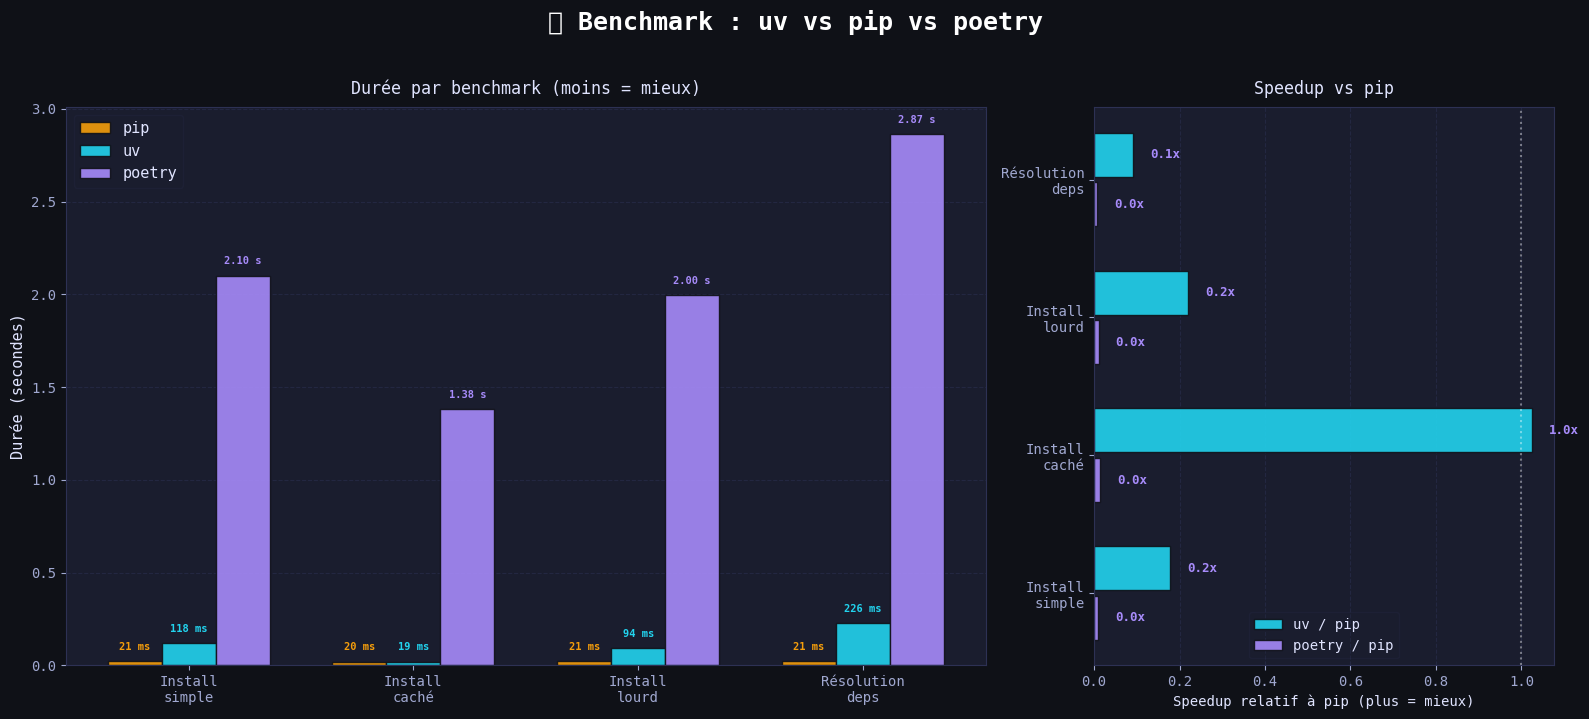

In [25]:
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d2e",
    "axes.edgecolor": "#2d3154", "axes.labelcolor": "#e0e4ff",
    "xtick.color": "#a0a8d0", "ytick.color": "#a0a8d0",
    "text.color": "#e0e4ff", "grid.color": "#2d3154",
    "grid.linestyle": "--", "grid.alpha": 0.5, "font.family": "monospace",
})

COLORS = {"pip": "#f59e0b", "uv": "#22d3ee", "poetry": "#a78bfa"}
LABELS = {
    "install_simple": "Install\nsimple",
    "install_cached": "Install\ncaché",
    "install_heavy":  "Install\nlourd",
    "resolve":        "Résolution\ndeps",
}

benchmarks = list(results.keys())
managers   = ["pip", "uv", "poetry"]
bar_w = 0.24
x     = np.arange(len(benchmarks))

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={"width_ratios": [2, 1]})
fig.suptitle("📦 Benchmark : uv vs pip vs poetry",
             fontsize=18, fontweight="bold", color="#ffffff", y=1.02)

ax1 = axes[0]
for i, mgr in enumerate(managers):
    vals = [results[b].get(mgr, 0) for b in benchmarks]
    bars = ax1.bar(x + i * bar_w, vals, bar_w, label=mgr,
                   color=COLORS[mgr], alpha=0.9, edgecolor="#0f1117")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                     fmt(v), ha="center", va="bottom",
                     fontsize=7.5, color=COLORS[mgr], fontweight="bold")

ax1.set_xticks(x + bar_w)
ax1.set_xticklabels([LABELS[b] for b in benchmarks], fontsize=10)
ax1.set_ylabel("Durée (secondes)", fontsize=11)
ax1.set_title("Durée par benchmark (moins = mieux)", fontsize=12, pad=10)
ax1.legend(fontsize=11, framealpha=0.2, edgecolor="#2d3154")
ax1.yaxis.grid(True); ax1.set_axisbelow(True)

ax2 = axes[1]
su_list = [results[b]["pip"] / results[b]["uv"]    for b in benchmarks]
sp_list = [results[b]["pip"] / results[b]["poetry"] for b in benchmarks]
y_pos   = np.arange(len(benchmarks))

ax2.barh(y_pos + 0.18, su_list, 0.32, color=COLORS["uv"],    alpha=0.9, label="uv / pip",     edgecolor="#0f1117")
ax2.barh(y_pos - 0.18, sp_list, 0.32, color=COLORS["poetry"], alpha=0.9, label="poetry / pip", edgecolor="#0f1117")
for i, (su, sp) in enumerate(zip(su_list, sp_list)):
    ax2.text(su + 0.04, i + 0.18, "%.1fx" % su, va="center",
             color=COLORS[mgr], fontweight="bold", fontsize=9)
    ax2.text(sp + 0.04, i - 0.18, "%.1fx" % sp, va="center",
             color=COLORS[mgr], fontweight="bold", fontsize=9)

ax2.axvline(1, color="#ffffff", linestyle=":", alpha=0.4, linewidth=1.5)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([LABELS[b] for b in benchmarks], fontsize=10)
ax2.set_xlabel("Speedup relatif à pip (plus = mieux)", fontsize=10)
ax2.set_title("Speedup vs pip", fontsize=12, pad=10)
ax2.legend(fontsize=10, framealpha=0.2, edgecolor="#2d3154")
ax2.xaxis.grid(True); ax2.set_axisbelow(True)

plt.tight_layout()

output_dir = "/mnt/user-data/outputs"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "benchmark_results.png"),
            dpi=150, bbox_inches="tight", facecolor="#0f1117")
print("Graphique sauvegardé ✅")

---
## 📋 Tableau récapitulatif

In [26]:
print("\n" + "=" * 70)
print(" RÉSULTATS COMPLETS")
print("=" * 70)
print("%-28s %12s %12s %12s %12s" % ("Benchmark", "pip", "uv", "poetry", "uv speedup"))
print("-" * 70)

names = {
    "install_simple": "Install simple (requests)",
    "install_cached": "Install avec cache",
    "install_heavy":  "Install lourd (np+pd+sc)",
    "resolve":        "Résolution dépendances",
}
for key, label in names.items():
    if key not in results: continue
    r = results[key]
    pip_t = r.get("pip", 0); uv_t = r.get("uv", 0); po_t = r.get("poetry", 0)
    sp = ("%.1fx" % (pip_t / uv_t)) if uv_t > 0 else "N/A"
    print("%-28s %12s %12s %12s %12s" % (label, fmt(pip_t), fmt(uv_t), fmt(po_t), sp))

print("=" * 70)

all_pip = [results[k]["pip"] for k in results]
all_uv  = [results[k]["uv"]  for k in results]
all_po  = [results[k]["poetry"] for k in results]

avg_uv = sum(p/u for p, u in zip(all_pip, all_uv)) / len(all_uv)
avg_po = sum(p/u for p, u in zip(all_pip, all_po)) / len(all_po)

print("\n🏆 Speedup moyen uv vs pip    : %.1fx plus rapide" % avg_uv)
print("🏅 Speedup moyen poetry vs pip: %.1fx" % avg_po)
print("\n📝 CONCLUSIONS")
print("-" * 50)
print("• uv     -> Vitesse maximale, idéal CI/CD, scripting")
print("• pip    -> Standard universel, aucune dépendance")
print("• poetry -> Meilleur pour projets + lock file robuste")


 RÉSULTATS COMPLETS
Benchmark                             pip           uv       poetry   uv speedup
----------------------------------------------------------------------
Install simple (requests)           21 ms       118 ms       2.10 s         0.2x
Install avec cache                  20 ms        19 ms       1.38 s         1.0x
Install lourd (np+pd+sc)            21 ms        94 ms       2.00 s         0.2x
Résolution dépendances              21 ms       226 ms       2.87 s         0.1x

🏆 Speedup moyen uv vs pip    : 0.4x plus rapide
🏅 Speedup moyen poetry vs pip: 0.0x

📝 CONCLUSIONS
--------------------------------------------------
• uv     -> Vitesse maximale, idéal CI/CD, scripting
• pip    -> Standard universel, aucune dépendance
• poetry -> Meilleur pour projets + lock file robuste


---
## 🗒️ Guide de choix

| Cas d'usage | Recommandation |
|---|---|
| CI/CD, Docker, scripts | ⚡ **uv** |
| Projets avec lock file | 🎯 **poetry** |
| Compatibilité maximale | 🔧 **pip** |
| Développement rapide | ⚡ **uv** |
| Publication sur PyPI | 🎯 **poetry** |

### Ressources
- [uv documentation](https://docs.astral.sh/uv/)
- [pip documentation](https://pip.pypa.io/)
- [poetry documentation](https://python-poetry.org/)